In [21]:
import ast
import math
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef
from tqdm import tqdm

In [22]:
test_accessions = open("../../../data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()
test_accessions = ['GCF_001277215.2', 'GCF_000006765.1', "GCF_000012765.1"] #REMOVE

In [23]:
def load_in_processed_datasets(test_accession, data_type):
    #Load in testset data
    with open(f"../../../data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as testset_dict_file:
        testset_dict = pickle.load(testset_dict_file)

    with open(f"../../../data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as read_names_list_file:
        read_names_list = pickle.load(read_names_list_file)

    with open(f"../../../data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl", "rb") as preds_prodigal_dict_file:
        preds_prodigal = pickle.load(preds_prodigal_dict_file)

    #Load in FGS predictions
    with open(f"../../../data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_illumina_5_dict = pickle.load(preds_fgs_dict_file)

    with open(f"../../../data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl", "rb") as preds_fgs_dict_file:
        preds_fgs_illumina_10_dict = pickle.load(preds_fgs_dict_file)

    #Load in Model preds
    with open(f"../../../data/processed_data/predictions/processed_predictions/model_shared_crf_preds/{data_type}/full_model_100_genomes_trained/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_model_8M_shared_nt_dict = pickle.load(model_preds_dict_file)

    with open(f"../../../data/processed_data/predictions/processed_predictions/model_shared_crf_preds/{data_type}/full_model_200_genomes_trained/{test_accession}/model_preds_dict.pkl", "rb") as model_preds_dict_file:
        preds_model_8M_nt_dict = pickle.load(model_preds_dict_file)


    return read_names_list, testset_dict, preds_prodigal, preds_fgs_illumina_5_dict, preds_fgs_illumina_10_dict, preds_model_8M_shared_nt_dict, preds_model_8M_nt_dict
    

In [24]:
def calculate_rates_for_rf(cds_rf_testset, cds_rf_preds, codons_per_rf, seq_len):

    seq_len_pred = seq_len - 3
    # Create boolean arrays for coverage
    pred_covered = np.zeros(seq_len_pred, dtype=bool)
    actual_covered = np.zeros(seq_len_pred, dtype=bool)

    # Mark covered positions for predictions
    for start, end in cds_rf_preds:
        pred_covered[start-1:end] = True  # assuming 1-based coordinates

    # Mark covered positions for actual/testset
    for start, end in cds_rf_testset:
        actual_covered[start-1:end] = True  # assuming 1-based coordinates

    # Calculate confusion matrix counts
    TP = int(np.sum(pred_covered & actual_covered) / 3)
    FP = int(np.sum(pred_covered & ~actual_covered) / 3)
    FN = int(np.sum(~pred_covered & actual_covered) / 3)
    TN = int(np.sum(~pred_covered & ~actual_covered) / 3)


    assert TP + FP + FN + TN == codons_per_rf

    return TP, FP, FN, TN

In [25]:
def matthews_corrcoef(TP, FP, FN, TN):
    """
    Compute Matthews Correlation Coefficient (MCC).
    
    Parameters
    ----------
    TP : int
        True positives
    FP : int
        False positives
    FN : int
        False negatives
    TN : int
        True negatives
    
    Returns
    -------
    float
        MCC value in range [-1, 1]. Returns 0 if denominator is 0.
    """
    numerator = (TP * TN) - (FP * FN)
    denominator = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    
    if denominator == 0:
        return 0.0  # convention: MCC = 0 when denominator is undefined
    
    return numerator / denominator

In [26]:
def f1_score_and_more(TP, FP, FN):
    """
    Compute F1 score from confusion matrix components.

    Parameters
    ----------
    TP : int
        True positives
    FP : int
        False positives
    FN : int
        False negatives

    Returns
    -------
    float
        F1 score in range [0, 1]. Returns 0 if precision+recall = 0.
    """
    if TP == 0 and (FP > 0 or FN > 0):
        return 0.0

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    if (precision + recall) == 0:
        return 0.0

    return 2 * (precision * recall) / (precision + recall), precision, recall

In [27]:
def calculate_performance_metrics_model(testset_dict, model_preds_dict, read_names_list, codons_total, codons_per_rf, seq_len):
    TN = 0
    TP = 0
    FP = 0
    FN = 0

    for read in read_names_list:
        coding_codons_len = 0
        

        #Non-coding read, predicted as non-coding
        if read not in testset_dict.keys() and read not in model_preds_dict.keys():
            TN += codons_total
        
        #Read contains CDS, no CDS predicted
        elif read in testset_dict.keys() and read not in model_preds_dict.keys():
            for cds_coord_set in testset_dict[read]["cds_coords"]:
                cds_coord_start = cds_coord_set[0]
                cds_coord_end = cds_coord_set[1]
                assert int(cds_coord_end - cds_coord_start + 1) % 3 == 0, "Something went wrong in codon calculations!"
                coding_codons_len += int((cds_coord_end - cds_coord_start + 1) / 3)

            FN += coding_codons_len 
            TN += (codons_total - coding_codons_len)
        
        #Non-coding read, some CDS predicted
        elif read not in testset_dict.keys() and read in model_preds_dict.keys():
            for cds_coord_set in model_preds_dict[read]["cds_coords"]:
                cds_coord_start = cds_coord_set[0]
                cds_coord_end = cds_coord_set[1]
                assert int(cds_coord_end - cds_coord_start + 1) % 3 == 0, "Something went wrong in codon calculations!"
                coding_codons_len += int((cds_coord_end - cds_coord_start + 1) / 3)

            FP += coding_codons_len
            TN += (codons_total - coding_codons_len)

        #Read contains CDS, CDS predicted
        elif read in testset_dict.keys() and read in model_preds_dict.keys():

            #print(read)
            #print(model_preds_dict[read]["cds_coords"])
            #print(testset_dict[read]["cds_coords"])
            #print()

            #If predicted and actual CDS positions are identical
            if model_preds_dict[read]["cds_coords"] == testset_dict[read]["cds_coords"]:
                for cds_coord_set in model_preds_dict[read]["cds_coords"]:
                    cds_coord_start = cds_coord_set[0]
                    cds_coord_end = cds_coord_set[1]
                    assert int(cds_coord_end - cds_coord_start + 1) % 3 == 0, "Something went wrong in codon calculations!"
                    coding_codons_len += int((cds_coord_end - cds_coord_start + 1) / 3)

                TP += coding_codons_len
                TN += (codons_total - coding_codons_len)

            #If there is discrepancy between predicted and actual CDS positions, handle carefully
            else:
                cds_rf0_testset = []
                cds_rf1_testset = []
                cds_rf2_testset = []

                cds_rf0_preds = []
                cds_rf1_preds = []
                cds_rf2_preds = []

                #Split testset CDS coordinates based on the reading frame they are placed in
                for cds_coords_testset in testset_dict[read]["cds_coords"]:

                    if cds_coords_testset[2] == '0':
                        cds_rf0_testset.append((cds_coords_testset[0], cds_coords_testset[1]))
                    elif cds_coords_testset[2] == '1':
                        cds_rf1_testset.append((cds_coords_testset[0]-1, cds_coords_testset[1]-1))
                    elif cds_coords_testset[2] == '2':
                        cds_rf2_testset.append((cds_coords_testset[0]-2, cds_coords_testset[1]-2))
                    else:
                        raise ValueError

                for cds_coords_preds in model_preds_dict[read]["cds_coords"]:
                    if cds_coords_preds[2] == '0':
                        cds_rf0_preds.append((cds_coords_preds[0], cds_coords_preds[1]))
                    elif cds_coords_preds[2] == '1':
                        cds_rf1_preds.append((cds_coords_preds[0]-1, cds_coords_preds[1]-1))
                    elif cds_coords_preds[2] == '2':
                        cds_rf2_preds.append((cds_coords_preds[0]-2, cds_coords_preds[1]-2))

                    else:
                        raise ValueError

                TP_rf0, FP_rf0, FN_rf0, TN_rf0 = calculate_rates_for_rf(cds_rf0_testset, cds_rf0_preds, codons_per_rf, seq_len)
                TP_rf1, FP_rf1, FN_rf1, TN_rf1 = calculate_rates_for_rf(cds_rf1_testset, cds_rf1_preds, codons_per_rf, seq_len)
                TP_rf2, FP_rf2, FN_rf2, TN_rf2 = calculate_rates_for_rf(cds_rf2_testset, cds_rf2_preds, codons_per_rf, seq_len)

                TP += (TP_rf0 + TP_rf1 + TP_rf2)
                FP += (FP_rf0 + FP_rf1 + FP_rf2)
                FN += (FN_rf0 + FN_rf1 + FN_rf2)
                TN += (TN_rf0 + TN_rf1 + TN_rf2)


        else:
            raise KeyError(f"Unexpected state for read {read}. Examine this.")
        
    mcc = matthews_corrcoef(TP, FP, FN, TN)
    f1_score, precision, recall = f1_score_and_more(TP, FP, FN)

    #print(f"MCC: {round(mcc, 3)}\tF1: {round(f1_score, 3)}\tPrecision: {round(precision, 3)}\t Recall: {round(recall, 3)}")

    return mcc, f1_score, precision, recall

In [28]:
def plot_mcc_per_genome_bars(performance_metrics_genomes_dict, data_type, model_display_names=None, colors=None):
    """
    Plot MCC performance metric across different genomes and models using bar charts.
    
    Args:
        performance_metrics_genomes_dict (dict): Dictionary containing genome accessions and model performance data
        model_display_names (dict, optional): Dictionary mapping model names to display names
        colors (list, optional): List of colors for the bars. If None, default colors will be used
    """
    
    # Extract genome accessions
    genome_accessions = list(performance_metrics_genomes_dict.keys())
    
    # Model names in order (based on your original code)
    model_names = ["MetaProdigal", "FGS (Illumina 0.5%)", "FGS (Illumina 1.0%)", 
                   'Full model, 100 genomes', 'Full model, 200 genomes']
                   #'ESM-2 8M + codon encoding (shared CRF)', 'ESM-2 8M + codon encoding']

    if not genome_accessions:
        print("No genome data found!")
        return
    
    # Set up display names
    if model_display_names is None:
        display_names = {name: name for name in model_names}
    else:
        display_names = model_display_names
    
    # Set up colors
    if colors is None:
        colors = ['skyblue', 'orange', 'orchid', 'forestgreen', 'purple']
    
    # Extract MCC scores for each model across all genomes
    # Each genome has a list of 4 results: [mcc, f1, precision, recall] for each of 4 models
    mcc_data = {}
    for i, model_name in enumerate(model_names):
        mcc_scores = []
        for genome in genome_accessions:
            # Get the MCC score (index 0) for model i
            mcc_score = performance_metrics_genomes_dict[genome][i][0]  # [mcc, f1, precision, recall]
            mcc_scores.append(mcc_score)
        mcc_data[model_name] = mcc_scores
    
    # Create x positions for the bars
    x = np.arange(len(genome_accessions))
    n_models = len(model_names)
    width = 0.8 / n_models  # Adjust width based on number of models
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(max(13, len(genome_accessions) * 1.3), 7))
    
    bars_list = []
    # Create bars for each model
    for i, model_name in enumerate(model_names):
        scores = mcc_data[model_name]
        # Filter out None values for plotting
        valid_scores = [score if score is not None else 0 for score in scores]
        
        x_pos = x - (n_models - 1) * width / 2 + i * width
        bars = ax.bar(x_pos, valid_scores, width, 
                     label=model_name,  # Use model_name directly since it's already clean
                     alpha=0.8, color=colors[i % len(colors)])
        bars_list.append(bars)
    
    # Customize the plot
    ax.set_ylabel('MCC', fontsize=12)
    ax.set_title(f'MCC Across Models and Genomes in Test Set (Codon-level) \n {data_type}', fontsize=14, fontweight='normal')
    ax.set_xticks(x)
    ax.set_xticklabels(genome_accessions, rotation=30, ha='right')
    
    # Adjust legend position based on number of models
    ncol = len(model_names)
    ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=ncol/2)
    
    # Add value labels on bars
    def add_value_labels(bars, scores):
        for bar, score in zip(bars, scores):
            if score is not None:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                       f'{height:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bars, model_name in zip(bars_list, model_names):
        add_value_labels(bars, mcc_data[model_name])
    
    # Set y-axis limits for better visualization (adjust based on your MCC range)
    min_mcc = min([min(scores) for scores in mcc_data.values() if scores])
    max_mcc = max([max(scores) for scores in mcc_data.values() if scores])
    y_range = max_mcc - min_mcc
    ax.set_ylim(max(0, min_mcc - 0.1 * y_range), min(1.0, max_mcc + 0.1 * y_range))
    
    # Add grid for better readability
    ax.grid(True, alpha=0.3, axis='y')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Display the plot
    plt.show()

# Main code

In [29]:
data_types = ["with_errors_5e-06i_0.004s_300bp",
              "with_errors_1.25e-05i_0.01s_300bp",
              "with_errors_3.75e-05i_0.03s_300bp"]

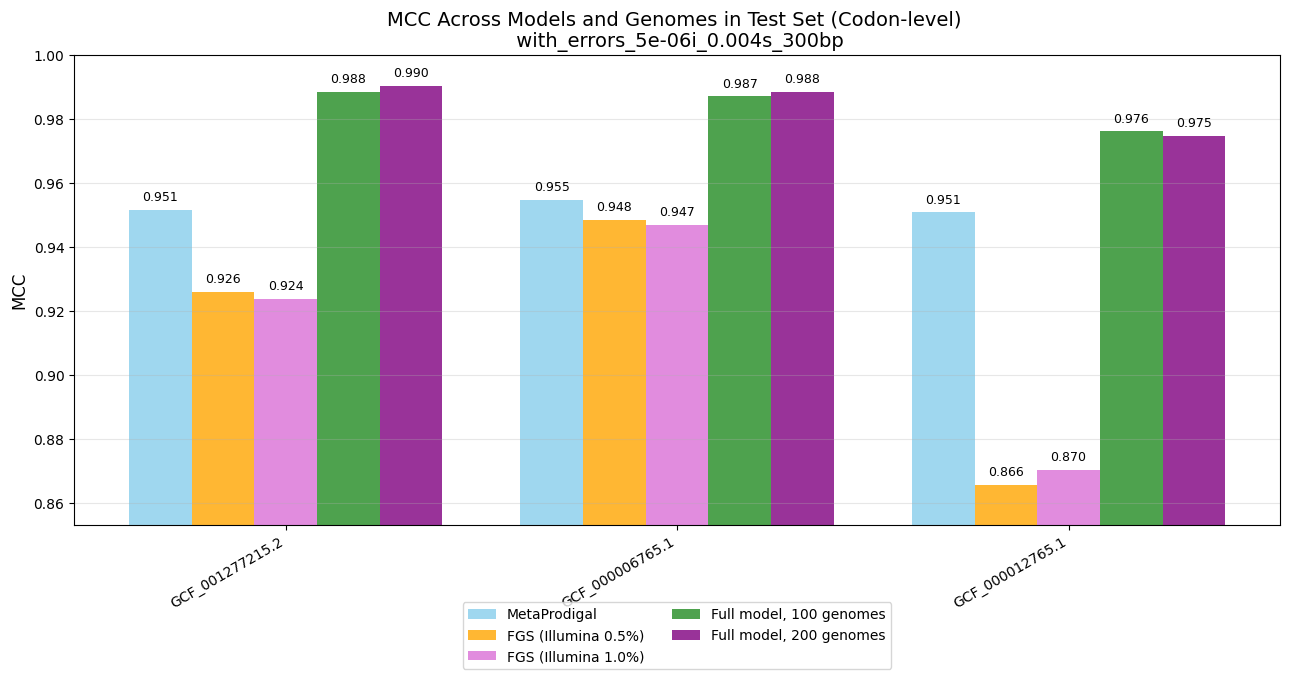

FileNotFoundError: [Errno 2] No such file or directory: '../../../data/processed_data/predictions/processed_predictions/model_shared_crf_preds/with_errors_1.25e-05i_0.01s_300bp/full_model_200_genomes_trained/GCF_001277215.2/model_preds_dict.pkl'

In [30]:
for data_type in data_types:

    if "150bp" in data_type:
        seq_len = 150
    elif "300bp" in data_type:
        seq_len = 300
    
    codons_per_rf = int((seq_len - 3) / 3)
    codons_total = int(codons_per_rf * 3)

    #Initialize
    performance_metrics_genomes_dict = {}
    # Store results in your existing loop
    for test_accession in test_accessions:
        read_names_list, testset_dict, preds_prodigal_dict, \
        preds_fgs_illumina_5_dict, preds_fgs_illumina_10_dict, \
        preds_model_8M_nt_shared_dict, preds_model_8M_nt_dict = load_in_processed_datasets(test_accession, data_type)

        # Calculate metrics for each model
        results = []
        for preds_dict in [preds_prodigal_dict, preds_fgs_illumina_5_dict, preds_fgs_illumina_10_dict, 
                           preds_model_8M_nt_shared_dict, preds_model_8M_nt_dict]:
            
            mcc, f1, precision, recall = calculate_performance_metrics_model(
                testset_dict, preds_dict, read_names_list, codons_total, codons_per_rf, seq_len)
            results.append([mcc, f1, precision, recall])
        
        performance_metrics_genomes_dict[test_accession] = results

    # Call the plotting function
    plot_mcc_per_genome_bars(performance_metrics_genomes_dict, data_type)